# Coursework 2 Part 1
**Replace CID in the file name with your CID**

# Outline


- [Task 1](#task-1): Classification with a Convolutional Neural Network <a name="index-task-1"></a>
  - [(1.1)](#task-11) <a name="index-task-11"></a>
  - [(1.2)](#task-12) <a name="index-task-12"></a>
- [Task 2](#task-2): Dimensionality Reduction with Non-Negative Matrix Tri-Factorisation <a name="index-task-2"></a>
  - [(2.1)](#task-21) <a name="index-task-21"></a>
  - [(2.2)](#task-22)  <a name="index-task-22"></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from matplotlib.pyplot import xlabel
from torch.nn import Sequential, CrossEntropyLoss, Conv1d, MaxPool1d, Dropout, Flatten, Linear, ReLU
from torch.utils.data import TensorDataset, DataLoader

In [2]:
def normalise(X):
    return (X - np.min(X)) / (np.max(X) - np.min(X))

def basic_graph(x, ys, labels, *, xlog=False, ylog=False, symlog=False, xlabel=None, ylabel=None, alpha=1):
    plt.figure(figsize=(12,8))
    for i, y in enumerate(ys.T):
        plt.plot(x, y, markersize=10, label=labels[i], alpha=alpha)
    plt.xlabel("x")
    plt.ylabel("y")
    if xlog:
        plt.xscale("log")
    if ylog:
        plt.yscale("log")
    if symlog:
        plt.yscale("symlog", linthresh=0.1)
    if xlabel is not None:
        plt.xlabel(xlabel)
    if ylabel is not None:
        plt.ylabel(ylabel)
    plt.legend()
    plt.show()

In [3]:
arr = pd.read_csv("neural_activity.csv").to_numpy()
x = arr[:, :-3].astype(float)
y = arr[:, -1]
subst_dict = {"R": 0, "L": 1, "F": 2, "B": 3}

N_regions = 40
N_trials = 80

x_norm = normalise(x)

In [4]:
x_r = x_norm.reshape(N_regions, N_trials, -1).transpose(1, 0, 2)
y_r = y.reshape(N_regions, N_trials).T
test_idx = [56, 30, 42, 63, 7, 66, 2, 77, 78, 13, 39, 61, 5, 67, 70, 46]
train_idx = [i for i in range(N_trials) if i not in test_idx]
x_test = x_r[test_idx, :, :]
x_train = x_r[train_idx, :, :]

y_test = y_r[test_idx, 0]
y_train = y_r[train_idx, 0]

y_test = np.array([subst_dict[label] for label in y_test])
y_train = np.array([subst_dict[label] for label in y_train])

N_trials_tr = len(train_idx)
N_trials_te = len(test_idx)

<a name="task-1"></a>

# Task 1: Classification with a Convolutional Neural Network [(index)](#index-task-1)

<a name="task-11"></a>

## (1.1) [(index)](#index-task-11)

In [5]:
def get_model(x_train, n_filters, k, pool_size, stride_pool, dropout, classes):
    """
    CNN model in PyTorch:
    - Layers are Conv1d(+ReLU), MaxPool1d, Flatten and Linear(+Softmax).
    - It features an Adam optimiser and CrossEntropyLoss criterion.

    Parameters:
        x_train (np.ndarray): Training data
        n_filters (int): Number of filters to be used in the convolutional layer
        k (int): Kernel size in the convolutional layer
        pool_size (int): MaxPool1d window size
        stride_pool (int): Stride of the MaxPool1d sliding window
        classes (List): Output classes

    Returns:
        Model, criterion and optimiser.

    """

    l_out_conv = x_train.shape[2] - k + 1  # Length after Conv1d (note that the stride is 1)
    l_out_pool = (l_out_conv - pool_size) // stride_pool + 1  # Length after MaxPool1d
    l_in_linear = n_filters * l_out_pool  # Size before Linear layer

    model = Sequential(
        Conv1d(x_train.shape[1], n_filters, kernel_size=k),
        ReLU(),
        MaxPool1d(kernel_size=pool_size, stride=stride_pool),
        Dropout(p=dropout),
        Flatten(),
        Linear(l_in_linear, len(classes)),
    )

    criterion = CrossEntropyLoss()
    optimiser = torch.optim.Adam(model.parameters())

    return model, criterion, optimiser

In [68]:
n_filters = 8
k = 16
pool_size = 16
stride_pool = 4
dropout = 0.8
classes = ["R", "L", "F", "B"]

torch.manual_seed(10)

model, criterion, optimiser = get_model(x_train, n_filters, k, pool_size, stride_pool, dropout, classes)
print(model)

Sequential(
  (0): Conv1d(40, 8, kernel_size=(16,), stride=(1,))
  (1): ReLU()
  (2): MaxPool1d(kernel_size=16, stride=4, padding=0, dilation=1, ceil_mode=False)
  (3): Dropout(p=0.8, inplace=False)
  (4): Flatten(start_dim=1, end_dim=-1)
  (5): Linear(in_features=344, out_features=4, bias=True)
)


In [7]:
xtr_tensor = torch.tensor(x_train, dtype=torch.float32)
xte_tensor = torch.tensor(x_test, dtype=torch.float32)
ytr_tensor = torch.tensor(y_train)
yte_tensor = torch.tensor(y_test)

train_dataset = TensorDataset(xtr_tensor, ytr_tensor.squeeze())
train_loader = DataLoader(train_dataset, batch_size=16)

In [8]:
def training_loop(train_loader, num_epochs=200):
    """
    Training loop for CNN.

    Parameters:
        train_loader (torch.utils.data.DataLoader): Training DataLoader
        num_epochs (int): Number of epochs

    Returns:
        Model, criterion and optimiser.

    """

    history = {'training_loss': [], 'training_accuracy': []}

    for epoch in range(num_epochs):

        tr_loss = 0.0
        tr_correct = 0

        # Training
        model.train()
        for inputs, labels in train_loader:
            optimiser.zero_grad() # Setting gradients to zero
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            tr_loss += loss.item()
            tr_correct += (outputs.argmax(dim=1) == labels).sum().item()
            loss.backward() # Computes gradients of the loss
            optimiser.step() # Optimisation step (parameters are updated)

        history['training_loss'].append(tr_loss/len(train_loader))
        history['training_accuracy'].append(100*tr_correct/len(train_dataset))

        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'Epoch {epoch + 1}/{num_epochs}, Training loss: {tr_loss/len(train_loader)}, Training accuracy: {100*tr_correct/len(train_dataset)}%')

    return history

In [9]:
num_epochs = 100

history = training_loop(train_loader, num_epochs)

Epoch 80/100, Training loss: 0.10083989333361387, Training accuracy: 95.3125%
Epoch 90/100, Training loss: 0.0580871757119894, Training accuracy: 100.0%
Epoch 100/100, Training loss: 0.046119009144604206, Training accuracy: 100.0%


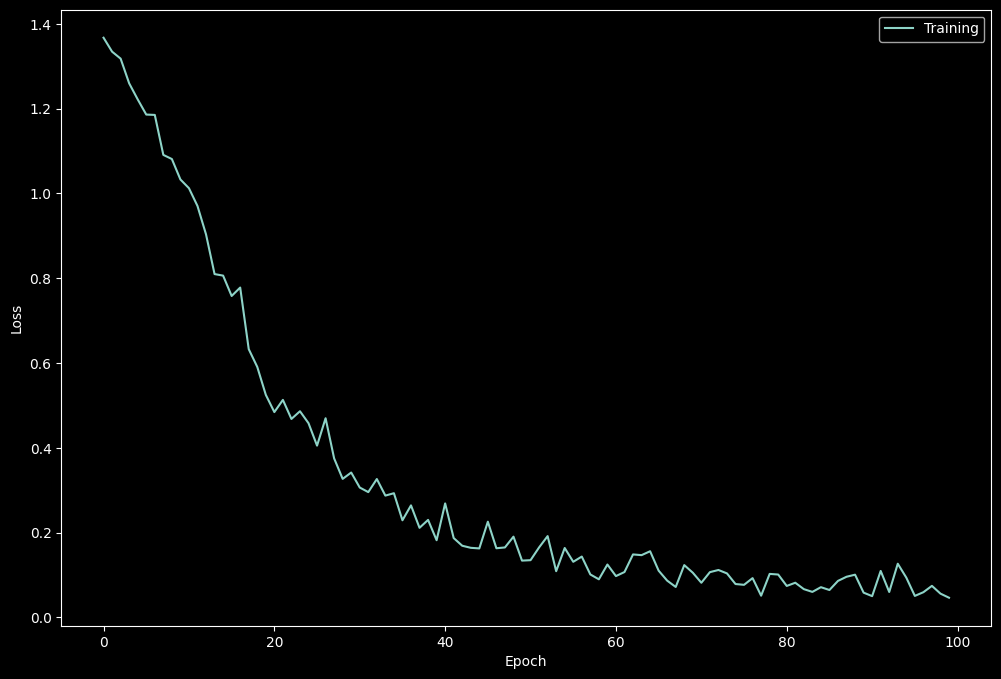

In [10]:
loss = np.vstack([history['training_loss']]).T
basic_graph(range(loss.shape[0]), loss, labels=["Training"], xlabel="Epoch", ylabel="Loss")

In [11]:
def pred_accuracy(pred, true):
    return sum(true == pred) / true.shape[0]

In [12]:
pred_train = torch.argmax(model(xtr_tensor), dim=1).detach().numpy()
pred_test = torch.argmax(model(xte_tensor), dim=1).detach().numpy()

print(f"Train set accuracy: {pred_accuracy(pred_train, y_train)}")
print(f"Test set accuracy: {pred_accuracy(pred_test, y_test)}")

Train set accuracy: 1.0
Test set accuracy: 0.9375


From the graph, we can see that our loss function does indeed converge -- with the final cross-entropy loss being $0.0461$ for the training set.

Testing the accuracy of our predictions using the argmax of the predicted class probabilities shows us that our test set accuracy is slightly lower than the training set accuracy, with our training and test accuracies being $100\%$ and $93.75\%$ respectively -- which indicates some level of overfitting.

<a name="task-12"></a>

## (1.2) [(index)](#index-task-12)

In [13]:
model.train()
preds = np.zeros((10, N_trials_te, len(classes)))
for j in range(10):
    pred = torch.softmax(model(xte_tensor), 1).detach().numpy()
    preds[j, :, :] = pred

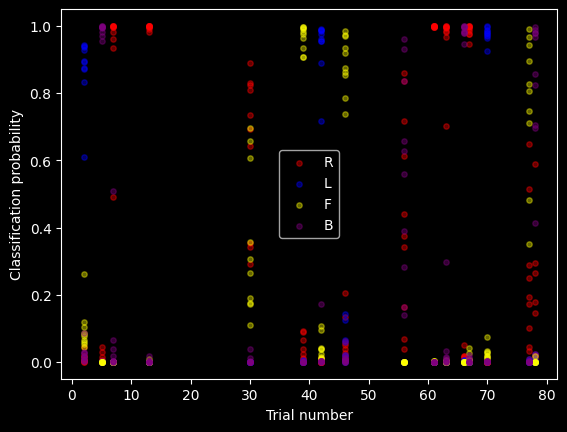

In [14]:
colours = ["r", "b", "yellow", "purple"]

for i in range(preds.shape[2]):
    xs = np.tile(np.array(test_idx)[list(range(N_trials_te))], 10)
    ys = preds[:, :, i].reshape(-1)
    plt.scatter(xs, ys, 15, colours[i], label=f"{classes[i]}", alpha=0.4)
plt.xlabel("Trial number")
plt.ylabel("Classification probability")
plt.legend()

When the model is set to training mode using `model.train()`, it performs the dropout step (as a part of the dropout layer), which is required for the training of the model, however when in evaluation mode (`model.eval()`) this dropout layer is not used. So, the difference between evaluating the predictions when set to training mode and evaluation mode is that in training mode, the dropout layer is still performed (ie. $80\%$ of the entries are zeroed).

Compared to evaluating while in evaluation mode, we see some accuracy loss. For example, in trial number $30$, some predictions predict label $R$ over label $F$, whereas in other predictions the inverse is predicted, implying there is some level of instability in the predictions. This could be due to the loss of information that occurs when zeroing some of the values in the dropout layer.

<a name="task-2"></a>

# Task 2: Dimensionality Reduction with Non-Negative Matrix Tri-Factorisation [(index)](#index-task-2)

In [15]:
rng = np.random.default_rng(0)

<a name="task-21"></a>

## (2.1) [(index)](#index-task-21)

In [16]:
def sq_eucnorm(X):
    return np.sum(np.multiply(X, X))

In [17]:
def norm_euc_cost_NMF(X, W, H):
    diff = X - W @ H
    return sq_eucnorm(diff) / sq_eucnorm(X)

In [18]:
def euclidean_NMF(X, r, rng, epsilon=0.0001, n_iters=500):
  """
  Implements NMF with the normalised euclidean cost function.

  Parameters:
    X (np.ndarray): Data matrix, shape (N, p).
    r (int): Number of components.
    rng (np.random.default_rng): Random number generator.
    epsilon (float): Small positive scalar, default 0.0001.
    n_iters (int): Number of iterations, default 500.

  Returns:
    W (np.ndarray): Weight matrix, shape (N, r).
    H (np.ndarray): Feature matrix, shape (r, p).
    cost_values (list): List of cost values for each iteration.
  """
  # N x r components matrix, usually interpreted as the weights of each feature
  W = rng.random((X.shape[0], r))
  # r x P matrix interpreted as the basis set
  H = rng.random((r, X.shape[1]))

  # empty list
  cost_values = []

  # loop over the n iterations
  for i in range(n_iters):
      # compute the update on W
      W = W * (X @ H.T) / (W @ H @ H.T + epsilon)
      # compute the update on H
      H = H * (W.T @ X) / (W.T @ W @ H + epsilon)
      # compute the cost and append to list
      cost_values.append(norm_euc_cost_NMF(X, W, H))
      if i % 50 == 0 or i == n_iters - 1:
        print(f"Iteration {i:5d} | Loss: {norm_euc_cost_NMF(X, W, H):10.4e}")

  return W, H, cost_values

In [19]:
r = 5
eps = 0.0001
n_iters = 500
W, H, cost_values_NMF = euclidean_NMF(x_norm, r, rng, eps, n_iters)

Iteration   499 | Loss: 2.9725e-02


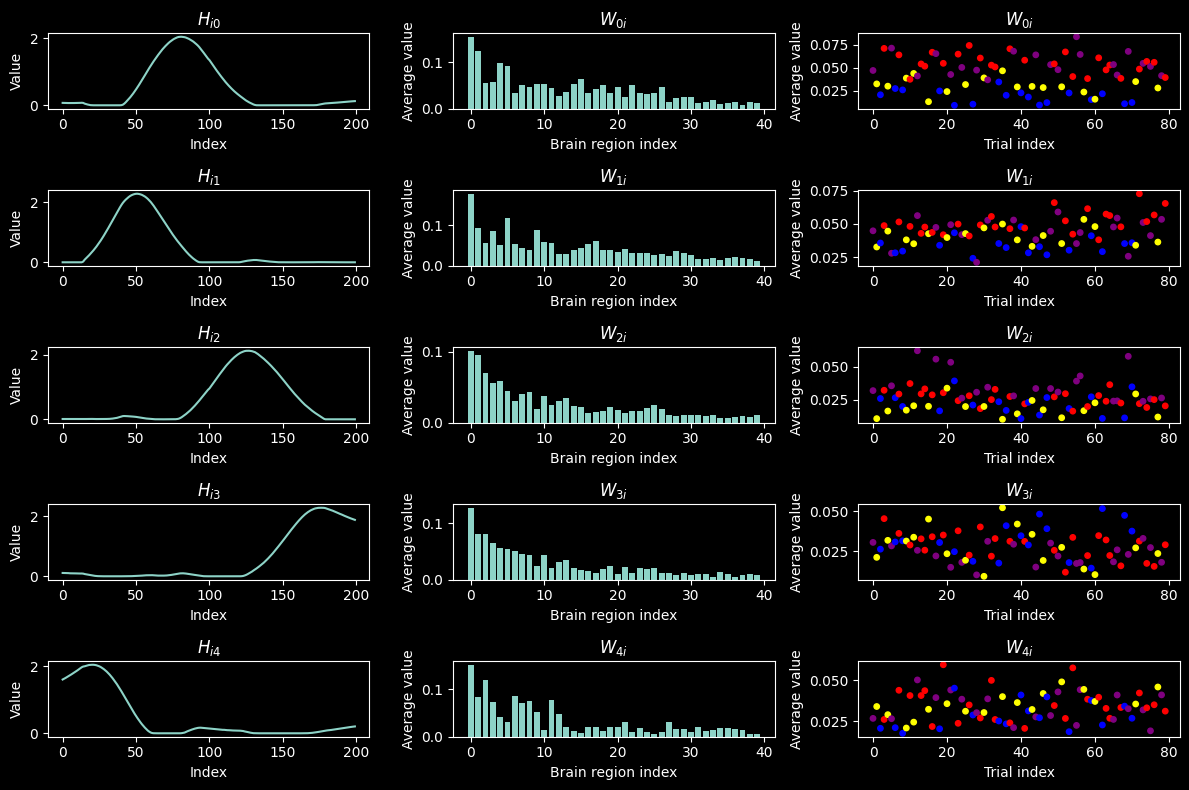

In [65]:
rows = r
cols = 3
fig, axs = plt.subplots(rows, cols, figsize=(12, 8))

for j in range(rows):
    # a)
    ax = axs[j, 0]
    h_row = H[j, :]
    n_feats = H.shape[1]
    ax.set_title(fr"$H_{{i{j}}}$")
    ax.set_xlabel("Index")
    ax.set_ylabel("Value")
    ax.plot(range(n_feats), h_row, '-')

    # b)
    ax = axs[j, 1]
    W_j = W[:, j]
    avgs = [np.mean(W_j[N_trials*i : N_trials*(i + 1)]) for i in range(N_regions)]
    ax.set_title(fr"$W_{{{j}i}}$")
    ax.set_xlabel("Brain region index")
    ax.set_ylabel("Average value")
    ax.bar(range(N_regions), avgs)

    # c)
    ax = axs[j, 2]
    idx = np.array([80*i for i in range(N_regions)])
    avgs = [np.mean(W_j[idx + i]) for i in range(N_trials)]
    colours = np.array(["r", "b", "yellow", "purple"])
    y_subst = [subst_dict[item] for item in y]
    cols = [colours[y_subst[i]] for i in range(N_trials)]
    ax.set_title(fr"$W_{{{j}i}}$")
    ax.set_xlabel("Trial index")
    ax.set_ylabel("Average value")
    ax.scatter(range(N_trials), avgs, s=15, c=cols)

fig.tight_layout()
fig.show()

<a name="task-22"></a>

## (2.2) [(index)](#index-task-22)

In [21]:
def norm_euc_cost_NMTF(X, U, S, V):
    diff = X - U @ S @ V.T
    return sq_eucnorm(diff) / sq_eucnorm(X)

In [22]:
def euclidean_NMTF(X, r1, r2, rng, epsilon=0.0001, n_iters=500):
  """
  Implements NMF with the normalised euclidean cost function.

  Parameters:
    X (np.ndarray): Data matrix, shape (N, p).
    r (int): Number of components.
    rng (np.random.default_rng): Random number generator.
    epsilon (float): Small positive scalar, default 0.0001.
    n_iters (int): Number of iterations, default 500.

  Returns:
    W (np.ndarray): Weight matrix, shape (N, r).
    H (np.ndarray): Feature matrix, shape (r, p).
    cost_values (list): List of cost values for each iteration.
  """
  U = rng.random((X.shape[0], r1))
  S = rng.random((r1, r2))
  V = rng.random((X.shape[1], r2))

  # empty list
  cost_values = []

  # loop over the n iterations
  for i in range(n_iters):
      # compute the update on U
      U = U * (X @ V @ S.T) / (U @ S @ V.T @ V @ S.T + epsilon)
      # compute the update on V
      V = V * (X.T @ U @ S) / (V @ S.T @ U.T @ U @ S + epsilon)
      # compute the update on S
      S = S * (U.T @ X @ V) / (U.T @ U @ S @ V.T @ V + epsilon)
      # compute the cost and append to list
      cost_values.append(norm_euc_cost_NMTF(X, U, S, V))
      if i % 50 == 0 or i == n_iters - 1:
        print(f"Iteration {i:5d} | Loss: {norm_euc_cost_NMTF(X, U, S, V):10.4e}")

  return U, S, V, cost_values

In [23]:
r1, r2 = 7, 5
eps = 1e-7
n_iters = 500
U, S, V, cost_values_NMTF = euclidean_NMTF(x_norm, r1, r2, rng, eps, n_iters)

Iteration   499 | Loss: 3.1507e-02


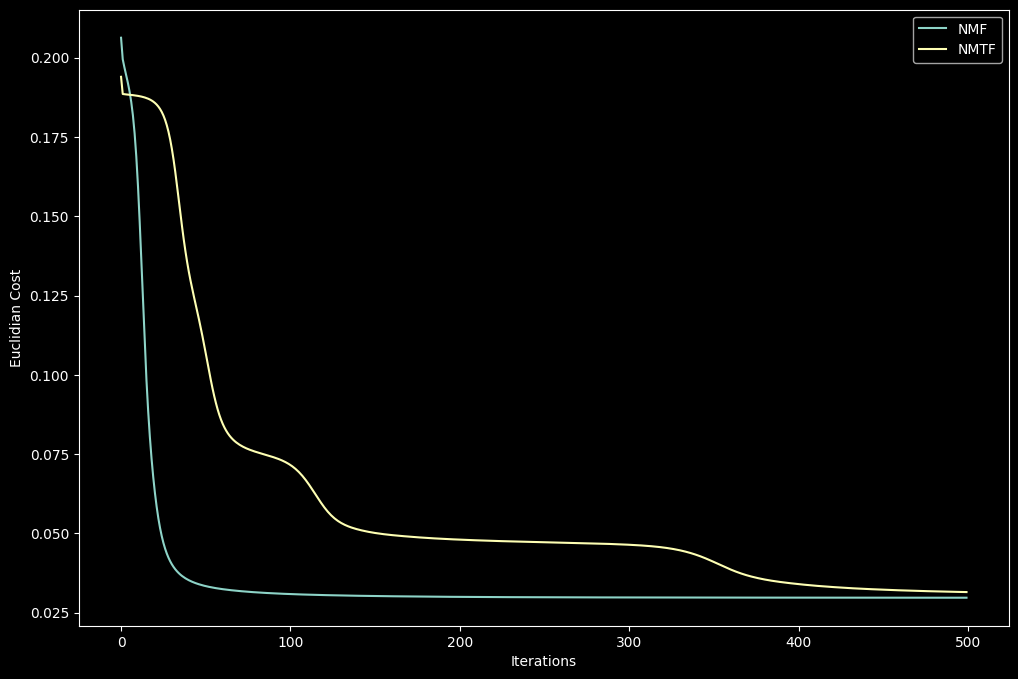

In [31]:
ys = np.array([cost_values_NMF, cost_values_NMTF]).T
basic_graph(range(n_iters), ys, labels=["NMF", "NMTF"], xlabel="Iterations", ylabel="Euclidian Cost")

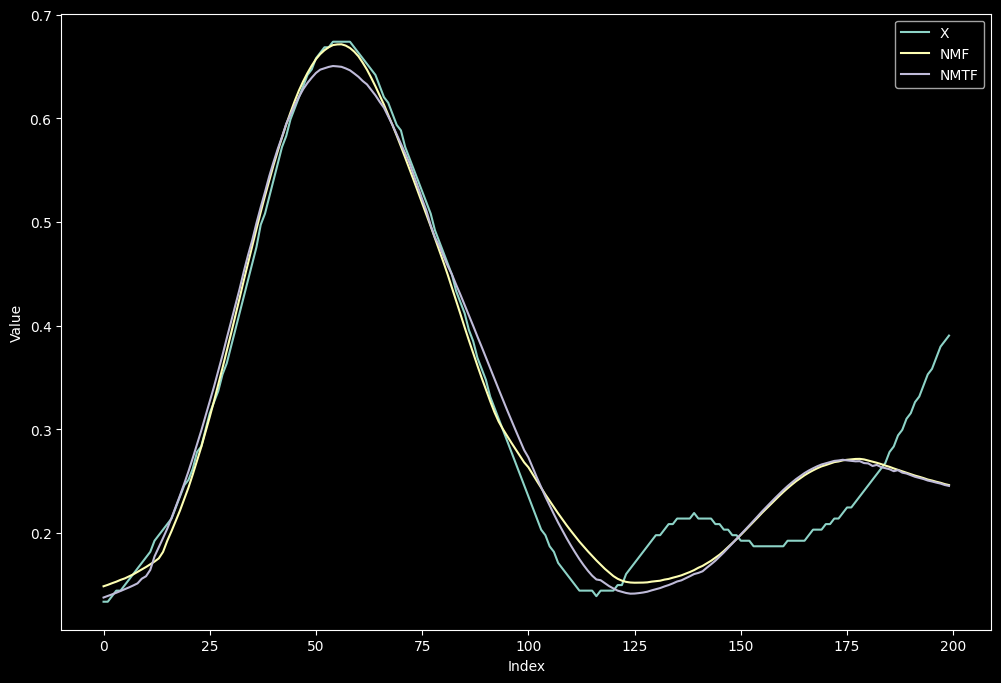

In [25]:
X_NMF = W @ H
X_NMTF = U @ S @ V.T

ys = np.vstack((x_norm[0, :], X_NMF[0, :], X_NMTF[0, :])).T
basic_graph(range(x_norm.shape[1]), ys, labels=["X", "NMF", "NMTF"], xlabel="Index", ylabel="Value")

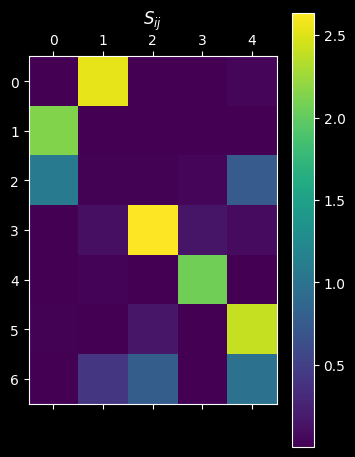

In [30]:
plt.matshow(S)
plt.colorbar()
plt.title(r"$S_{ij}$")

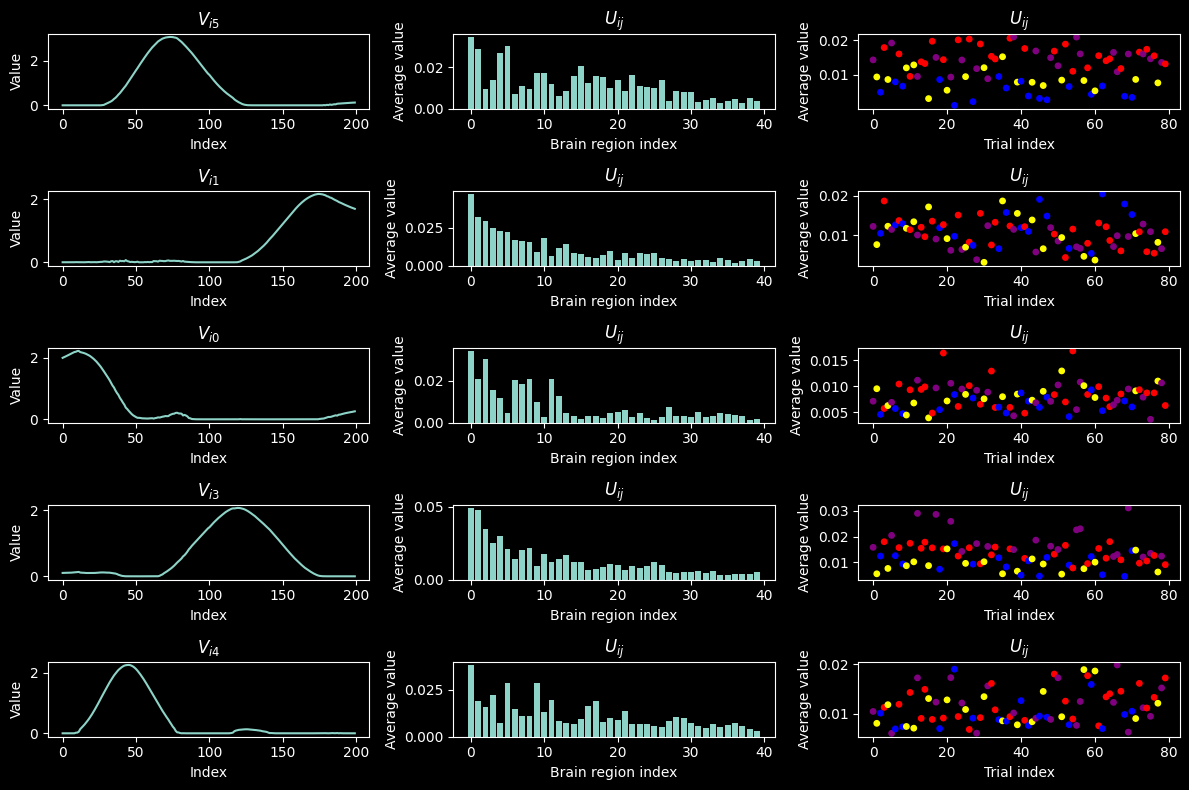

In [67]:
rows = r2
cols = 3
fig, axs = plt.subplots(rows, cols, figsize=(12, 8))

for n in range(rows):
    # d)
    ax = axs[n, 0]
    v_row = V.T[n, :]
    n_feats = V.T.shape[1]
    ax.plot(range(n_feats), v_row, '-')
    ax.set_title(fr"$V_{{i{j}}}$")
    ax.set_xlabel("Index")
    ax.set_ylabel("Value")

    # e)
    s_row = S[:, n]
    j = np.argmax(s_row)

    # f)
    ax = axs[n, 1]
    U_j = U[:, j]
    avgs = [np.mean(U_j[N_trials*i : N_trials*(i + 1)]) for i in range(N_regions)]
    ax.bar(range(N_regions), avgs)
    ax.set_title(fr"$U_{{ij}}$")
    ax.set_xlabel("Brain region index")
    ax.set_ylabel("Average value")

    # g)
    ax = axs[n, 2]
    idx = np.array([80*i for i in range(N_regions)])
    avgs = [np.mean(U_j[idx + i]) for i in range(N_trials)]
    colours = np.array(["r", "b", "yellow", "purple"])
    y_subst = [subst_dict[item] for item in y]
    cols = [colours[y_subst[i]] for i in range(N_trials)]
    ax.scatter(range(N_trials), avgs, s=15, c=cols)
    ax.set_title(fr"$U_{{ij}}$")
    ax.set_xlabel("Trial index")
    ax.set_ylabel("Average value")

fig.tight_layout()
fig.show()